# Business Understanding

## Problem Statements

Penyakit jantung adalah penyebab utama kematian di seluruh dunia.

Deteksi dini dapat meningkatkan hasil pengobatan secara signifikan.

Analisis manual faktor risiko memakan waktu dan rentan terhadap kesalahan manusia.

## Goals

Mengembangkan model prediksi yang akurat untuk risiko penyakit jantung.

Mengidentifikasi faktor risiko utama yang berkontribusi terhadap penyakit jantung.

Membuat alat yang dapat membantu tenaga medis dalam deteksi dini.

## Solution Statements

Menerapkan model Artificial Neural Network (ANN) untuk memprediksi penyakit jantung.

Menggunakan analisis pentingnya fitur untuk mengidentifikasi faktor risiko utama.

Mengembangkan antarmuka yang mudah digunakan untuk penilaian risiko.

# Data Understanding

## Import data dari kaggle

In [244]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"deliafebrianti","key":"a7e2233bad19c3c30dac6db9b4ca792a"}'}

In [232]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [233]:
!kaggle datasets download -d mdimran6666/heart-disease-nowadays

Dataset URL: https://www.kaggle.com/datasets/mdimran6666/heart-disease-nowadays
License(s): unknown
heart-disease-nowadays.zip: Skipping, found more recently modified local copy (use --force to force download)


In [234]:

!unzip heart-disease-nowadays.zip


Archive:  heart-disease-nowadays.zip
replace Heart Disease.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Heart Disease.csv       


## Import Library yang dibutuhkan

In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pickle

## Exploratory Data Analysis

In [236]:
df = pd.read_csv("Heart Disease.csv")

In [237]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


In [238]:
df.info()
print(df.isnull().sum())
print(df['HeartDisease'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  int64  
 6   MentalHealth      319795 non-null  int64  
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  int64  
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

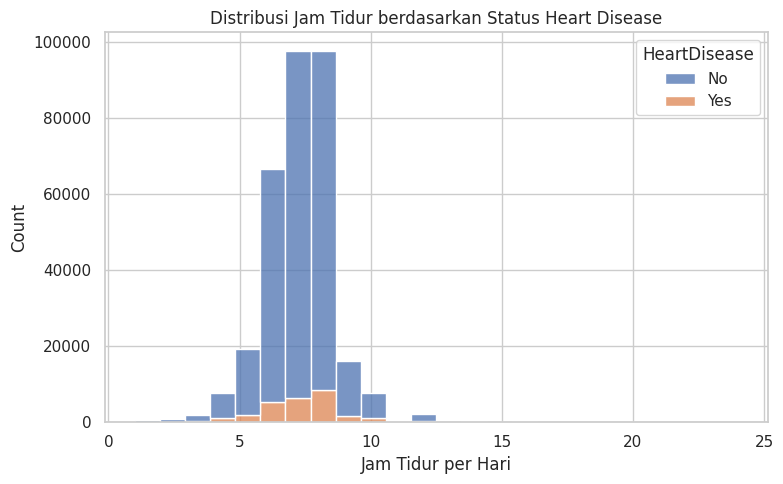

In [239]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="SleepTime", hue="HeartDisease", multiple="stack", bins=24)
plt.title("Distribusi Jam Tidur berdasarkan Status Heart Disease")
plt.xlabel("Jam Tidur per Hari")
plt.tight_layout()
plt.show()


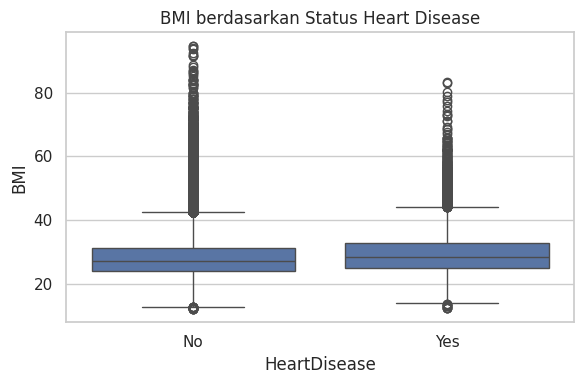

In [240]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="HeartDisease", y="BMI")
plt.title("BMI berdasarkan Status Heart Disease")
plt.xticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.show()



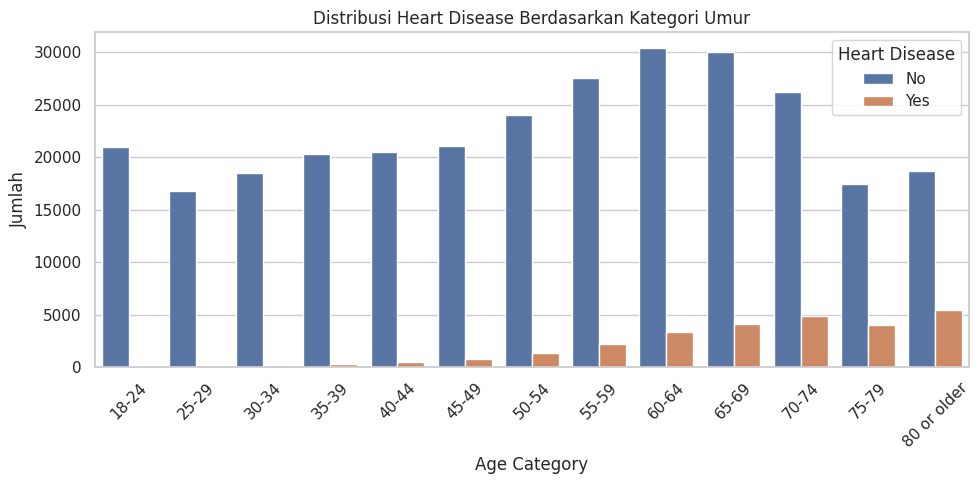

In [241]:
plt.figure(figsize=(10, 5))
order = df["AgeCategory"].value_counts().sort_index().index
sns.countplot(data=df, x="AgeCategory", hue="HeartDisease", order=order)
plt.title("Distribusi Heart Disease Berdasarkan Kategori Umur")
plt.xticks(rotation=45)
plt.xlabel("Age Category")
plt.ylabel("Jumlah")
plt.legend(title="Heart Disease", labels=["No", "Yes"])
plt.tight_layout()
plt.show()



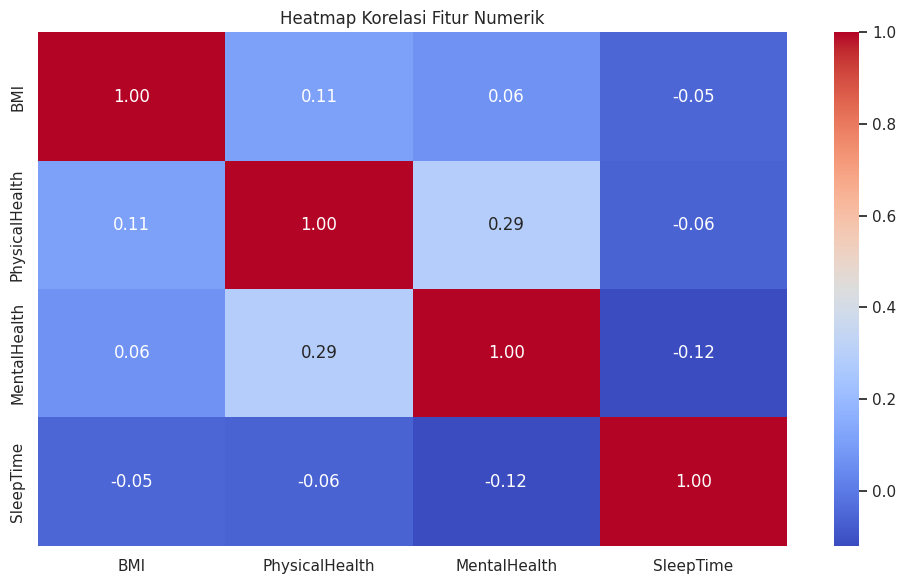

In [242]:
plt.figure(figsize=(10, 6))
numerik = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numerik.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

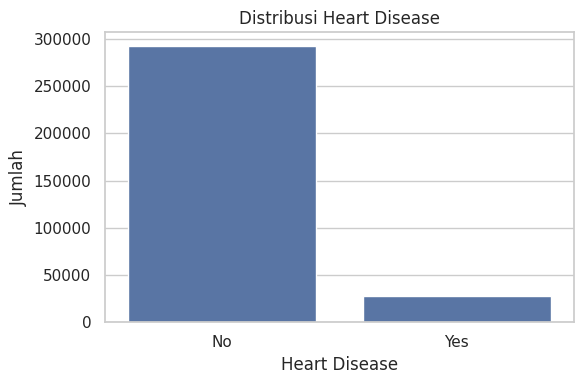

In [243]:
plt.figure(figsize=(6, 4))
sns.countplot(x="HeartDisease", data=df)
plt.title("Distribusi Heart Disease")
plt.xticks([0, 1], ["No", "Yes"])
plt.xlabel("Heart Disease")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()


# Data Preparation

In [201]:
print(df.head())

  HeartDisease    BMI Smoking AlcoholDrinking Stroke  PhysicalHealth  \
0           No  16.60     Yes              No     No               3   
1           No  20.34      No              No    Yes               0   
2           No  26.58     Yes              No     No              20   
3           No  24.21      No              No     No               0   
4           No  23.71      No              No     No              28   

   MentalHealth DiffWalking     Sex  AgeCategory   Race Diabetic  \
0            30          No  Female        55-59  White      Yes   
1             0          No  Female  80 or older  White       No   
2            30          No    Male        65-69  White      Yes   
3             0          No  Female        75-79  White       No   
4             0         Yes  Female        40-44  White       No   

  PhysicalActivity  GenHealth  SleepTime Asthma KidneyDisease SkinCancer  
0              Yes  Very good          5    Yes            No        Yes  
1       

In [202]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']


In [203]:
categorical_cols = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le


In [204]:
le_target = LabelEncoder()
y = le_target.fit_transform(y)

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [206]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modeling

In [207]:
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [208]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [209]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [211]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/50
7995/7995 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9148 - loss: 0.2296 - val_accuracy: 0.9159 - val_loss: 0.2301
Epoch 2/50
7995/7995 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.9144 - loss: 0.2290 - val_accuracy: 0.9156 - val_loss: 0.2295
Epoch 3/50
7995/7995 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.9161 - loss: 0.2260 - val_accuracy: 0.9162 - val_loss: 0.2283
Epoch 4/50
7995/7995 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.9151 - loss: 0.2284 - val_accuracy: 0.9160 - val_loss: 0.2288
Epoch 5/50
7995/7995 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9159 - loss: 0.2272 - val_accuracy: 0.9157 - val_loss: 0.2287
Epoch 6/50
7995/7995 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9150 - loss: 0.2277 - val_accuracy: 0.9153 - val_loss: 0.2288
Epoch 7/50
7995/7995 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9151 - loss: 0.2279 - val_accuracy: 0.9155 - val_loss: 0.2288
Epoch 8/50
7995/7995 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9148 - loss: 0

In [212]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy*100:.2f}%')

1999/1999 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9158 - loss: 0.2298
Test Accuracy: 91.62%


# Evaluation

1999/1999 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9158 - loss: 0.2298
Test Accuracy: 91.62%
1999/1999 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     58484
           1       0.59      0.07      0.12      5475

    accuracy                           0.92     63959
   macro avg       0.76      0.53      0.54     63959
weighted avg       0.89      0.92      0.88     63959



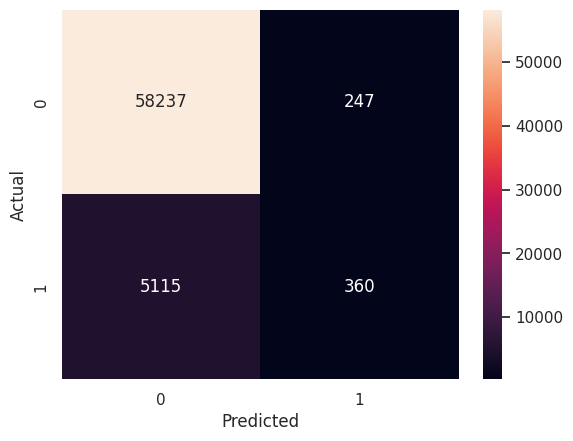

In [214]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy*100:.2f}%')

# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Deployment

## Model Simulation

In [219]:
# Function to preprocess new data
def preprocess_input(data, label_encoders, scaler):
    df = pd.DataFrame([data])
    for col in df.select_dtypes(include=['object']).columns:
        if col in label_encoders:
            df[col] = label_encoders[col].transform(df[col])
    return scaler.transform(df)

# Example new data
new_data = {
    'BMI': 28.5,
    'Smoking': 'Yes',
    'AlcoholDrinking': 'No',
    'Stroke': 'No',
    'PhysicalHealth': 5,
    'MentalHealth': 10,
    'DiffWalking': 'No',
    'Sex': 'Male',
    'AgeCategory': '55-59',
    'Race': 'White',
    'Diabetic': 'No',
    'PhysicalActivity': 'Yes',
    'GenHealth': 'Good',
    'SleepTime': 7,
    'Asthma': 'No',
    'KidneyDisease': 'No',
    'SkinCancer': 'No'
}

# Load preprocessing objects
with open('label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('target_encoder.pkl', 'rb') as f:
    le_target = pickle.load(f)

# Preprocess and predict
processed_data = preprocess_input(new_data, label_encoders, scaler)
prediction = model.predict(processed_data)
risk = "High Risk" if prediction > 0.5 else "Low Risk"
probability = prediction[0][0] * 100

print(f"Prediction: {risk} ({probability:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Prediction: Low Risk (13.54%)


## Save Model

In [220]:

model.save('heart_disease_model.h5')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('heart_disease_model.tflite', 'wb') as f:
    f.write(tflite_model)



Saved artifact at '/tmp/tmpct_bvxew'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 17), dtype=tf.float32, name='keras_tensor_59')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140163574875728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140163574885520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140163574878224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140163574876880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140163574882064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140163574883024: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [221]:
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save target label encoder
with open('target_encoder.pkl', 'wb') as f:
    pickle.dump(le_target, f)